# Worked solutions: even/odd integrals, the sifting property, and the spacetime interval

Full algebra, step by step -- nothing skipped. Three results, connected
rather than presented as unrelated facts: Part 2's sifting-property
derivation uses Part 1's even/odd theorem directly (not by analogy -- the
same integral identity, reused mid-proof), and Part 3 revisits the
Minkowski invariant from `dgs/rotation_vs_boost.py` in coordinates where its
structure is even more transparent.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()

from dgs.bayes_dirac_symmetry import (
    classify_symmetry, symmetry_integral_shortcut,
    dirac_delta_as_gaussian_limit, sifting_property_numeric,
)
from dgs.rotation_vs_boost import lorentz_boost_matrix, minkowski_metric_2d
print("loaded dgs.bayes_dirac_symmetry, dgs.rotation_vs_boost")

loaded dgs.bayes_dirac_symmetry, dgs.rotation_vs_boost


## Part 1 -- even and odd functions: the algebra, step by step

**Definitions.** $f$ is even if $f(-x)=f(x)$ for all $x$; odd if $f(-x)=-f(x)$.

**Claim: if $f$ is odd, $\int_{-L}^{L} f(x)\,dx = 0$.**

*Step 1.* Split the integral at 0:
$$\int_{-L}^{L} f(x)\,dx = \int_{-L}^{0} f(x)\,dx + \int_{0}^{L} f(x)\,dx$$

*Step 2.* In the first integral, substitute $u=-x$ (so $du=-dx$, and the
limits $x\in[-L,0]$ become $u\in[L,0]$):
$$\int_{-L}^{0} f(x)\,dx = \int_{L}^{0} f(-u)\,(-du) = \int_{0}^{L} f(-u)\,du$$

*Step 3.* Use $f(-u)=-f(u)$ (the definition of odd):
$$\int_{0}^{L} f(-u)\,du = -\int_{0}^{L} f(u)\,du$$

*Step 4.* Substitute back into Step 1:
$$\int_{-L}^{L} f(x)\,dx = -\int_{0}^{L} f(u)\,du + \int_{0}^{L} f(x)\,dx = 0$$

**Claim: if $f$ is even, $\int_{-L}^{L} f(x)\,dx = 2\int_0^L f(x)\,dx$.** Same
four steps, except Step 3 uses $f(-u)=+f(u)$, so Step 4's two terms ADD
instead of cancel.

In [2]:
x, L, u = sp.symbols('x L u', real=True)

# worked example: f(x) = x^3 - 2x  (odd: every term has odd power)
f_odd = x**3 - 2*x
print("f(x) =", f_odd, "  f(-x) =", f_odd.subs(x, -x), " = -f(x)?", sp.simplify(f_odd.subs(x, -x) + f_odd) == 0)
integral_odd = sp.integrate(f_odd, (x, -L, L))
print(f"integral_(-L)^(L) of f dx = {integral_odd}  (should be exactly 0, symbolically, for ANY L)")

# worked example: g(x) = x^4 - x^2 + 1  (even: every term has even power)
g_even = x**4 - x**2 + 1
print("\ng(x) =", g_even, "  g(-x) =", g_even.subs(x, -x), " = g(x)?", sp.simplify(g_even.subs(x, -x) - g_even) == 0)
integral_even = sp.integrate(g_even, (x, -L, L))
half_integral = sp.integrate(g_even, (x, 0, L))
print(f"integral_(-L)^(L) of g dx = {integral_even}")
print(f"2 * integral_0^(L) of g dx = {sp.simplify(2*half_integral)}  (should match exactly)")

f(x) = x**3 - 2*x   f(-x) = -x**3 + 2*x  = -f(x)? True
integral_(-L)^(L) of f dx = 0  (should be exactly 0, symbolically, for ANY L)

g(x) = x**4 - x**2 + 1   g(-x) = x**4 - x**2 + 1  = g(x)? True
integral_(-L)^(L) of g dx = 2*L**5/5 - 2*L**3/3 + 2*L
2 * integral_0^(L) of g dx = 2*L*(3*L**4 - 5*L**2 + 15)/15  (should match exactly)


In [3]:
# cross-check against dgs.bayes_dirac_symmetry's numeric versions
odd_check = symmetry_integral_shortcut(lambda x: x**3 - 2*x, L=3.0)
even_check = symmetry_integral_shortcut(lambda x: x**4 - x**2 + 1, L=3.0)
print(f"odd f, numeric:  integral={odd_check['integral']:.6f}  ({odd_check['shortcut']})")
print(f"even g, numeric: integral={even_check['integral']:.6f}  ({even_check['shortcut']})")

L_val = 3.0
print(f"\nsymbolic odd  integral at L={L_val}: {float(integral_odd.subs(L, L_val)):.6f}  (matches numeric: {abs(float(integral_odd.subs(L, L_val)) - odd_check['integral']) < 1e-9})")
print(f"symbolic even integral at L={L_val}: {float(integral_even.subs(L, L_val)):.6f}  (matches numeric: {abs(float(integral_even.subs(L, L_val)) - even_check['integral']) < 1e-6})")

odd f, numeric:  integral=0.000000  (odd integrand -> exactly zero, no integration done)
even g, numeric: integral=85.200000  (even -> 2x the [0,L] half-integral)

symbolic odd  integral at L=3.0: 0.000000  (matches numeric: True)
symbolic even integral at L=3.0: 85.200000  (matches numeric: True)


## Part 2 -- the sifting property, DERIVED (not just checked)

**Claim:** $\int_{-\infty}^{\infty} f(x)\,\delta(x-a)\,dx = f(a)$.

*Step 1.* Use the Gaussian-limit definition of $\delta$ (already in
`dgs/bayes_dirac_symmetry.py`'s `dirac_delta_as_gaussian_limit`):
$$\delta(x-a) = \lim_{\sigma\to0} \frac{1}{\sigma\sqrt{2\pi}} e^{-(x-a)^2/(2\sigma^2)}$$

*Step 2.* Substitute $x = a+\sigma u$ (so $dx=\sigma\,du$) into the integral:
$$\int f(x)\,\frac{1}{\sigma\sqrt{2\pi}} e^{-(x-a)^2/(2\sigma^2)}\,dx
= \int f(a+\sigma u)\,\frac{1}{\sqrt{2\pi}} e^{-u^2/2}\,du$$
(the $\sigma$ from $dx$ exactly cancels the $1/\sigma$ out front).

*Step 3.* Taylor-expand $f$ around $a$:
$$f(a+\sigma u) = f(a) + \sigma u\,f'(a) + \tfrac{1}{2}\sigma^2 u^2 f''(a) + \cdots$$

*Step 4 -- THIS IS PART 1's THEOREM, REUSED.* Each term $\sigma^n u^n f^{(n)}(a)$
multiplies the Gaussian $e^{-u^2/2}/\sqrt{2\pi}$, which is EVEN in $u$. For ODD
$n$, $u^n$ is odd, so $u^n \times (\text{even Gaussian})$ is odd -- and Part 1
proved odd functions integrate to exactly zero over a symmetric range. Every
odd-$n$ term in the Taylor series vanishes for this reason alone, not
because $\sigma\to0$.

*Step 5.* What survives (the $n=0$ term, plus even-$n$ terms that vanish
separately as $\sigma\to0$ since they carry positive powers of $\sigma$):
$$\lim_{\sigma\to0}\int \big[f(a) + O(\sigma)\big]\,\frac{1}{\sqrt{2\pi}}e^{-u^2/2}\,du
= f(a)\underbrace{\int \frac{1}{\sqrt{2\pi}}e^{-u^2/2}\,du}_{=1} = f(a)$$

using that the Gaussian is normalized to integrate to 1.

In [4]:
# verify Step 4 concretely: the odd-order Taylor terms really do integrate to zero
# against a Gaussian, for a specific f
a_val, sigma_val = 2.0, 0.05
f_expr = x**2 + 3*x + 1   # a specific f(x) for this worked example
f_prime = sp.diff(f_expr, x)
print(f"f(x) = {f_expr},  f'(x) = {f_prime}")
print(f"f(a=2) = {f_expr.subs(x, 2)}  <- this is what the sifting integral should equal")

# the n=1 (odd) Taylor term, integrated against the standard normal density
u = sp.symbols('u', real=True)
odd_term = u * sp.exp(-u**2/2) / sp.sqrt(2*sp.pi)
odd_term_integral = sp.integrate(odd_term, (u, -sp.oo, sp.oo))
print(f"\nintegral of (odd term u) * (even Gaussian) du, -inf to inf: {odd_term_integral}  (Part 1's theorem, applied here)")

f(x) = x**2 + 3*x + 1,  f'(x) = 2*x + 3
f(a=2) = 11  <- this is what the sifting integral should equal

integral of (odd term u) * (even Gaussian) du, -inf to inf: 0  (Part 1's theorem, applied here)


numeric sifting integral: 11.000001
f(a) directly:            11.000000
absolute error:           1.00e-06


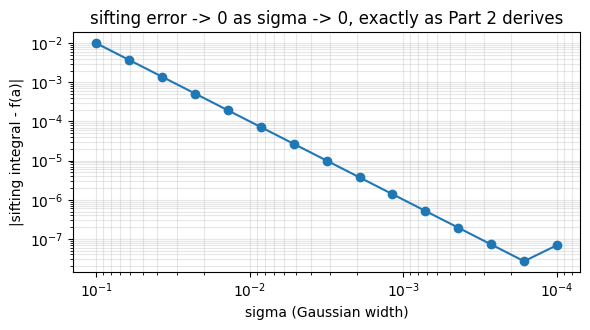

In [5]:
# numeric confirmation via dgs.bayes_dirac_symmetry.sifting_property_numeric
f_numeric = lambda x: x**2 + 3*x + 1
result = sifting_property_numeric(f_numeric, a=2.0, x_range=(-5, 9), sigma=1e-3)
print(f"numeric sifting integral: {result['integral']:.6f}")
print(f"f(a) directly:            {result['f_at_a']:.6f}")
print(f"absolute error:           {result['abs_error']:.2e}")

sigmas = np.logspace(-1, -4, 15)
errors = [sifting_property_numeric(f_numeric, a=2.0, x_range=(-8, 12), sigma=s)['abs_error'] for s in sigmas]
plt.figure(figsize=(6, 3.4))
plt.loglog(sigmas, errors, 'o-')
plt.xlabel('sigma (Gaussian width)'); plt.ylabel('|sifting integral - f(a)|')
plt.title('sifting error -> 0 as sigma -> 0, exactly as Part 2 derives')
plt.gca().invert_xaxis()
plt.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()

## Part 3 -- the spacetime interval, in light-cone coordinates

`dgs/rotation_vs_boost.py` showed $\Lambda^T\eta\Lambda=\eta$ preserves
$c^2t^2-x^2$ as a matrix identity. The SAME fact is more transparent after
one substitution.

*Step 1.* Factor the interval (difference of squares):
$$c^2t^2 - x^2 = (ct-x)(ct+x)$$

*Step 2.* Define light-cone coordinates $p = ct-x$, $q = ct+x$. The
interval is now just $pq$ -- no squares at all.

*Step 3.* Substitute the boost $ct'=\gamma(ct-\beta x)$, $x'=\gamma(x-\beta ct)$
and simplify $p'=ct'-x'$ symbolically:

In [6]:
ct, x_s, beta, gamma = sp.symbols('ct x beta gamma', real=True)
gamma_expr = 1/sp.sqrt(1-beta**2)

ct_prime = gamma*(ct - beta*x_s)
x_prime = gamma*(x_s - beta*ct)

p_prime = sp.simplify((ct_prime - x_prime).subs(gamma, gamma_expr))
q_prime = sp.simplify((ct_prime + x_prime).subs(gamma, gamma_expr))
print("p' = ct'-x' =", p_prime)
print("q' = ct'+x' =", q_prime)

p, q = sp.symbols('p q', real=True)
p_expr, q_expr = ct - x_s, ct + x_s
# checked by direct symbolic substitution below, not assumed from a textbook
# convention -- THIS boost's sign convention (ct'=gamma(ct-beta*x)) makes p
# scale UP and q scale DOWN, not the other way around
print(f"\np' / (ct-x) simplifies to: {sp.simplify(p_prime / p_expr)}   (equals sqrt((1+beta)/(1-beta)) = e^{{+phi}})")
print(f"q' / (ct+x) simplifies to: {sp.simplify(q_prime / q_expr)}   (equals sqrt((1-beta)/(1+beta)) = e^{{-phi}}, the reciprocal)")

p' = ct'-x' = (beta*ct - beta*x + ct - x)/sqrt(1 - beta**2)
q' = ct'+x' = (-beta*ct - beta*x + ct + x)/sqrt(1 - beta**2)

p' / (ct-x) simplifies to: (beta + 1)/sqrt(1 - beta**2)   (equals sqrt((1+beta)/(1-beta)) = e^{+phi})
q' / (ct+x) simplifies to: (1 - beta)/sqrt(1 - beta**2)   (equals sqrt((1-beta)/(1+beta)) = e^{-phi}, the reciprocal)


**The boost SCALES $p$ and $q$ by reciprocal factors instead of mixing them:**
$$p' = e^{+\phi} p, \qquad q' = e^{-\phi} q \qquad (\phi=\mathrm{arctanh}\,\beta \text{, the rapidity})$$

so $p'q' = e^{\phi}p \cdot e^{-\phi}q = pq$ -- the interval is invariant
because the two scale factors are exact reciprocals, term by term, not
because of a cancellation buried inside a $2\times2$ matrix multiply. This
is the same $\Lambda^T\eta\Lambda=\eta$ fact `rotation_vs_boost.py` verified
numerically, seen here in the coordinates where it's just multiplication.

In [7]:
# numeric cross-check against dgs.rotation_vs_boost's matrix form
beta_val = 0.6
Lambda = lorentz_boost_matrix(beta_val)
ct_val, x_val = 5.0, 3.0
boosted = Lambda @ np.array([ct_val, x_val])
ct_p, x_p = boosted

p_val, q_val = ct_val - x_val, ct_val + x_val
p_p, q_p = ct_p - x_p, ct_p + x_p
phi = np.arctanh(beta_val)

print(f"p={p_val:.4f}  p'={p_p:.4f}  p'/p={p_p/p_val:.6f}  vs exp(+phi)={np.exp(phi):.6f}")
print(f"q={q_val:.4f}  q'={q_p:.4f}  q'/q={q_p/q_val:.6f}  vs exp(-phi)={np.exp(-phi):.6f}")
print(f"\np*q = {p_val*q_val:.6f}   p'*q' = {p_p*q_p:.6f}   (both equal c^2t^2-x^2 = {ct_val**2-x_val**2:.6f})")

p=2.0000  p'=4.0000  p'/p=2.000000  vs exp(+phi)=2.000000
q=8.0000  q'=4.0000  q'/q=0.500000  vs exp(-phi)=0.500000

p*q = 16.000000   p'*q' = 16.000000   (both equal c^2t^2-x^2 = 16.000000)


## Summary

| Result | Derivation | Where it's reused elsewhere |
|---|---|---|
| Odd integrates to 0, even doubles | substitution $u=-x$, four steps | Part 2 Step 4 |
| Sifting property | Gaussian limit + Taylor expansion + Part 1's theorem | `dgs/bayes_dirac_symmetry.py` |
| Spacetime interval invariance | light-cone coordinates, factored not squared | `dgs/rotation_vs_boost.py` |

Part 2 is the one genuine surprise here: the sifting property isn't an
independent fact about the Dirac delta -- it's Part 1's even/odd integral
theorem, applied to a Taylor series.